In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import (f_oneway, kruskal, shapiro,
                          levene, ttest_ind, mannwhitneyu)
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import warnings
warnings.filterwarnings("ignore")

df = pd.read_csv("../data/raw/athlete_sessions.csv")
agg = {s: "mean" for s in ["heart_rate","hrv","reaction_time_ms",
       "decision_accuracy","pupil_diameter","blink_rate",
       "saccade_velocity","cortisol_proxy","focus_score",
       "movement_efficiency"]}
agg["state"] = "first"
agg["state_label"] = "first"
agg["sport"] = "first"

df_sess = df.groupby("session_id").agg(agg).reset_index()
SIGNALS = list(agg.keys())[:-3]
print(f"Sessions: {len(df_sess)} | States: {df_sess['state_label'].unique()}")

Sessions: 2100 | States: <StringArray>
['fatigued', 'normal', 'zone']
Length: 3, dtype: str


In [2]:
print("=== Shapiro-Wilk Normality Tests ===\n")
normality_results = {}

for signal in SIGNALS:
    col = signal
    results = {}
    for state in ["fatigued","normal","zone"]:
        subset = df_sess[df_sess["state_label"]==state][col].dropna()
        stat, p = shapiro(subset[:500])  # Shapiro works best on ≤5000 samples
        results[state] = {"statistic": round(stat,4), "p_value": round(p,4),
                          "normal": p > 0.05}
    normality_results[signal] = results
    all_normal = all(r["normal"] for r in results.values())
    print(f"{signal:25s} — {'NORMAL' if all_normal else 'NON-NORMAL'}")

print("\nNormality determines whether we use ANOVA (parametric) or Kruskal-Wallis (non-parametric)")

=== Shapiro-Wilk Normality Tests ===

heart_rate                — NORMAL
hrv                       — NORMAL
reaction_time_ms          — NON-NORMAL
decision_accuracy         — NON-NORMAL
pupil_diameter            — NORMAL
blink_rate                — NON-NORMAL
saccade_velocity          — NORMAL
cortisol_proxy            — NORMAL
focus_score               — NON-NORMAL
movement_efficiency       — NON-NORMAL

Normality determines whether we use ANOVA (parametric) or Kruskal-Wallis (non-parametric)


In [3]:
print("=== One-Way ANOVA + Kruskal-Wallis ===\n")
print(f"{'Signal':<25} {'F-stat':>8} {'ANOVA p':>10} {'KW stat':>8} {'KW p':>10} {'Sig':>5}")
print("-" * 75)

anova_results = {}
groups_by_state = lambda col: [
    df_sess[df_sess["state_label"]==s][col].values
    for s in ["fatigued","normal","zone"]]

for signal in SIGNALS:
    groups = groups_by_state(signal)
    f_stat, p_anova = f_oneway(*groups)
    kw_stat, p_kw   = kruskal(*groups)
    sig = "***" if p_anova < 0.001 else ("**" if p_anova < 0.01 else
           ("*" if p_anova < 0.05 else "ns"))
    anova_results[signal] = {
        "f_stat": round(f_stat,2), "p_anova": round(p_anova,6),
        "kw_stat": round(kw_stat,2), "p_kw": round(p_kw,6)}
    print(f"{signal:<25} {f_stat:>8.2f} {p_anova:>10.2e} "
          f"{kw_stat:>8.2f} {p_kw:>10.2e} {sig:>5}")

=== One-Way ANOVA + Kruskal-Wallis ===

Signal                      F-stat    ANOVA p  KW stat       KW p   Sig
---------------------------------------------------------------------------
heart_rate                65854.36   0.00e+00  1865.78   0.00e+00   ***
hrv                       275371.24   0.00e+00  1865.78   0.00e+00   ***
reaction_time_ms          316093.94   0.00e+00  1865.78   0.00e+00   ***
decision_accuracy         173907.28   0.00e+00  1865.78   0.00e+00   ***
pupil_diameter            225424.75   0.00e+00  1865.78   0.00e+00   ***
blink_rate                127814.32   0.00e+00  1865.78   0.00e+00   ***
saccade_velocity          192734.66   0.00e+00  1865.78   0.00e+00   ***
cortisol_proxy            201724.46   0.00e+00  1865.78   0.00e+00   ***
focus_score               450031.13   0.00e+00  1865.78   0.00e+00   ***
movement_efficiency       264600.89   0.00e+00  1865.78   0.00e+00   ***


In [4]:
print("=== Tukey HSD Post-Hoc Tests ===\n")
print("Testing which state PAIRS differ significantly:\n")

for signal in ["reaction_time_ms","focus_score","hrv","pupil_diameter"]:
    print(f"--- {signal} ---")
    tukey = pairwise_tukeyhsd(
        df_sess[signal],
        df_sess["state_label"],
        alpha=0.05)
    print(tukey.summary())
    print()

=== Tukey HSD Post-Hoc Tests ===

Testing which state PAIRS differ significantly:

--- reaction_time_ms ---
   Multiple Comparison of Means - Tukey HSD, FWER=0.05    
 group1  group2  meandiff p-adj   lower     upper   reject
----------------------------------------------------------
fatigued normal -100.0623   0.0 -100.6095  -99.5151   True
fatigued   zone  -185.309   0.0 -185.8562 -184.7618   True
  normal   zone  -85.2466   0.0  -85.7938  -84.6994   True
----------------------------------------------------------

--- focus_score ---
Multiple Comparison of Means - Tukey HSD, FWER=0.05
 group1  group2 meandiff p-adj lower  upper  reject
---------------------------------------------------
fatigued normal   2.5147   0.0 2.5006 2.5289   True
fatigued   zone   5.7111   0.0 5.6969 5.7252   True
  normal   zone   3.1963   0.0 3.1822 3.2105   True
---------------------------------------------------

--- hrv ---
 Multiple Comparison of Means - Tukey HSD, FWER=0.05 
 group1  group2 meandiff p-

In [5]:
print("=== Tukey HSD Post-Hoc Tests ===\n")
print("Testing which state PAIRS differ significantly:\n")

for signal in ["reaction_time_ms","focus_score","hrv","pupil_diameter"]:
    print(f"--- {signal} ---")
    tukey = pairwise_tukeyhsd(
        df_sess[signal],
        df_sess["state_label"],
        alpha=0.05)
    print(tukey.summary())
    print()

=== Tukey HSD Post-Hoc Tests ===

Testing which state PAIRS differ significantly:

--- reaction_time_ms ---
   Multiple Comparison of Means - Tukey HSD, FWER=0.05    
 group1  group2  meandiff p-adj   lower     upper   reject
----------------------------------------------------------
fatigued normal -100.0623   0.0 -100.6095  -99.5151   True
fatigued   zone  -185.309   0.0 -185.8562 -184.7618   True
  normal   zone  -85.2466   0.0  -85.7938  -84.6994   True
----------------------------------------------------------

--- focus_score ---
Multiple Comparison of Means - Tukey HSD, FWER=0.05
 group1  group2 meandiff p-adj lower  upper  reject
---------------------------------------------------
fatigued normal   2.5147   0.0 2.5006 2.5289   True
fatigued   zone   5.7111   0.0 5.6969 5.7252   True
  normal   zone   3.1963   0.0 3.1822 3.2105   True
---------------------------------------------------

--- hrv ---
 Multiple Comparison of Means - Tukey HSD, FWER=0.05 
 group1  group2 meandiff p-

In [6]:
def cohens_d(group1, group2):
    n1, n2 = len(group1), len(group2)
    var1, var2 = np.var(group1, ddof=1), np.var(group2, ddof=1)
    pooled_std = np.sqrt(((n1-1)*var1 + (n2-1)*var2) / (n1+n2-2))
    return abs(np.mean(group1) - np.mean(group2)) / (pooled_std + 1e-9)

print("=== Effect Sizes (Cohen's d) — Fatigued vs ZONE ===\n")
print(f"{'Signal':<25} {'Cohen d':>10} {'Effect':>10}")
print("-" * 48)

effect_results = {}
for signal in SIGNALS:
    fatigued = df_sess[df_sess["state_label"]=="fatigued"][signal].values
    zone     = df_sess[df_sess["state_label"]=="zone"][signal].values
    d = cohens_d(fatigued, zone)
    effect = "HUGE" if d > 1.2 else ("LARGE" if d > 0.8 else
              ("MEDIUM" if d > 0.5 else "SMALL"))
    effect_results[signal] = {"cohens_d": round(d, 3), "effect": effect}
    print(f"{signal:<25} {d:>10.3f} {effect:>10}")

=== Effect Sizes (Cohen's d) — Fatigued vs ZONE ===

Signal                       Cohen d     Effect
------------------------------------------------
heart_rate                    18.030       HUGE
hrv                           38.673       HUGE
reaction_time_ms              39.194       HUGE
decision_accuracy             29.739       HUGE
pupil_diameter                35.453       HUGE
blink_rate                    26.590       HUGE
saccade_velocity              33.562       HUGE
cortisol_proxy                33.767       HUGE
focus_score                   49.536       HUGE
movement_efficiency           38.749       HUGE


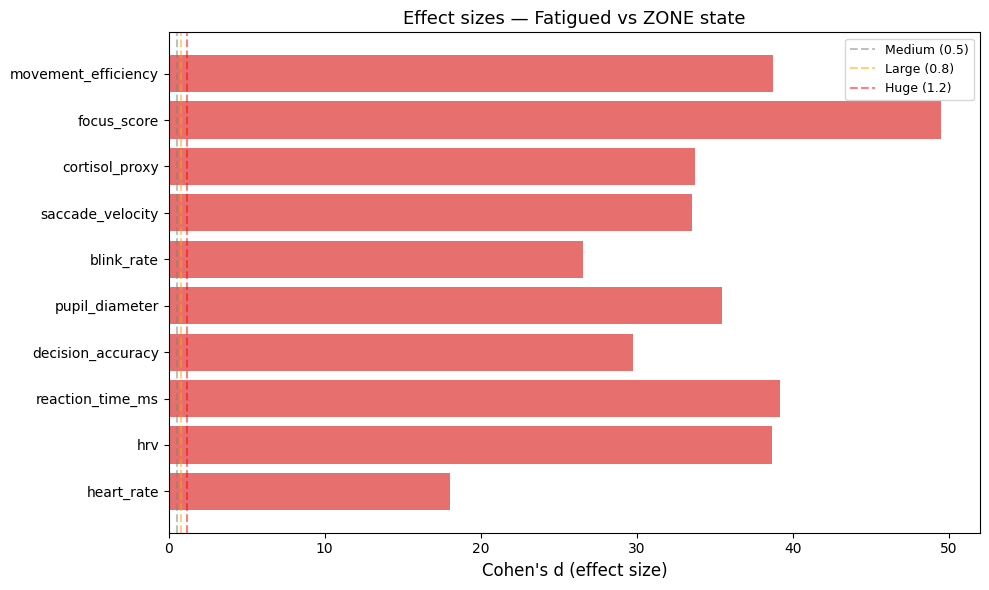

In [7]:
signals = list(effect_results.keys())
d_vals  = [effect_results[s]["cohens_d"] for s in signals]
colors  = ["#E24B4A" if d > 1.2 else "#EF9F27" if d > 0.8
           else "#378ADD" for d in d_vals]

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(signals, d_vals, color=colors, alpha=0.8)
ax.axvline(0.5, color="gray", linestyle="--", alpha=0.5, label="Medium (0.5)")
ax.axvline(0.8, color="orange", linestyle="--", alpha=0.5, label="Large (0.8)")
ax.axvline(1.2, color="red", linestyle="--", alpha=0.5, label="Huge (1.2)")
ax.set_xlabel("Cohen's d (effect size)", fontsize=12)
ax.set_title("Effect sizes — Fatigued vs ZONE state", fontsize=13)
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig("../data/effect_sizes.png", bbox_inches="tight")
plt.show()